In [1]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device(drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:1', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:3', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 78521)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 53143)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 40625)

# #### Device() ####
# device = cuda:1

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:1)
# edge_attr                (32464, 16)              Tensor (cuda:1)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:1)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path            

In [2]:
from modules.layers import MultiheadSetPooling
from modules.model import Dims, Encoder, Latent, BaseAutoencoder
from modules.norm import LogCounts, NBVST
from modules.train import Loader
from modules.utils import dict_summary
import torch
import torch.nn as nn

In [3]:
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)

dims = Dims(
    dataset=dataset,
    embed_dim=64,
    num_heads=4,
    method='set'
)

enc = Encoder(
    dims=dims,
    method='set',

    norm_class=NBVST,
    encoder_class=nn.Linear,
    pooling_class=MultiheadSetPooling,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',
)

lat = Latent(
    dims=dims,
    pooling_class=MultiheadSetPooling,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',
)

enc.init_with_loader(loader)

out = enc(_batch, need_weights=True)
out = lat(out, need_weights=True)

print(out.keys())

dict_keys(['x', 'x_t', 'layer_outs', 'h_node', 'h_pool', 'z_mu', 'z_logvar', 'z'])


In [4]:
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)

ae = BaseAutoencoder(
    dataset=dataset,
    embed_dim=64,
    num_heads=4,
    method='set',

    norm_class=NBVST,
    encoder_class=nn.Linear,
    pooling_class=MultiheadSetPooling,
    variational=True,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',
)

ae.init_with_loader(loader)

out = ae(_batch, need_weights=False)
# out = ae(_batch, need_weights=False)
if isinstance(out, torch.Tensor):
    print(out.shape)
elif isinstance(out, dict):
    print(dict_summary(out))
else:
    print(out)

# x_t                      (279872, 1)              Tensor (cuda:1)
# z_mu                     (64, 64)                 Tensor (cuda:1)
# z_logvar                 (64, 64)                 Tensor (cuda:1)
# x_preds                  (279872, 1)              Tensor (cuda:1)



---

In [5]:
from modules.loss import KLDLoss, reduce_loss

In [6]:
def kld_test(mu, logvar):
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    return kl


In [7]:
kld_test(out['z_mu'], out['z_logvar'])

tensor([5.7901, 5.7899, 5.7921, 5.7949, 5.7902, 5.7868, 5.7861, 5.7918, 5.7919,
        5.7892, 5.7885, 5.7913, 5.7867, 5.7888, 5.7878, 5.7942, 5.7883, 5.7875,
        5.7922, 5.7935, 5.7919, 5.7908, 5.7889, 5.7933, 5.7888, 5.7929, 5.7917,
        5.7951, 5.7890, 5.7908, 5.7916, 5.7895, 5.7916, 5.7864, 5.7960, 5.7954,
        5.7900, 5.7899, 5.7904, 5.7907, 5.7950, 5.7873, 5.7871, 5.7899, 5.7870,
        5.7944, 5.7947, 5.7891, 5.7899, 5.7875, 5.7893, 5.7882, 5.7870, 5.7943,
        5.7917, 5.7867, 5.7954, 5.7884, 5.7875, 5.7876, 5.7909, 5.7897, 5.7899,
        5.7857], device='cuda:1', grad_fn=<MulBackward0>)

In [8]:
kld_fn = KLDLoss()
kld_fn(mu=out['z_mu'], logvar=out['z_logvar'])

tensor(5.7903, device='cuda:1', grad_fn=<MeanBackward0>)

---

In [9]:
from modules.trainers import ReconstrTrainer
from modules.norm import RawCounts, LogCounts, NBVST
from modules.loss import MultiLoss

In [10]:
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)

trainer = ReconstrTrainer(
    lr=1e-3, 
    norm_class=LogCounts,
    out_keys={'input':'x_preds', 'target':'x_t', 'mu':'z_mu', 'logvar':'z_logvar'},
    loss_class=MultiLoss,
    loss_kwargs={
        'loss_classes': [nn.MSELoss, KLDLoss],
        # 'ema_norm': True,
        'loss_weights': (1,1e-5),
        # 'warmup':40*7
    }
)

ae = BaseAutoencoder(
    dataset=dataset,
    embed_dim=128,
    num_heads=4,
    method='set',

    norm_class=LogCounts,
    encoder_class=nn.Linear,
    pooling_class=MultiheadSetPooling,
    variational=True,

    hidden_dims=2,
    act_fn=nn.ReLU,
    norm_fn='layer',

    norm_kwargs={'libnorm':True, 'znorm':True, 'learnable':True}
)

trainer.run(
    model=ae,
    loader=loader,
    num_epochs=200,
    report_metrics=['loss','kld','rmse','mae','r2'],
    verbose=True
)

  0%|          | 0/200 [00:00<?, ?it/s]

Test	 loss=0.2240    kld=92.3119    rmse=0.7903    mae=0.5265    r2=0.8400



In [11]:
out = trainer.model(_batch, need_weights=True)
# out = ae(_batch, need_weights=False)
if isinstance(out, torch.Tensor):
    print(out.shape)
elif isinstance(out, dict):
    print(dict_summary(out))
else:
    print(out)



# x_t                      (279872, 1)              Tensor (cuda:1)
# layer_outs               4                        dict
# h_node                   (64, 4373, 128)          Tensor (cuda:1)
# h_pool                   (64, 305, 128)           Tensor (cuda:1)
# z_mu                     (64, 128)                Tensor (cuda:1)
# z_logvar                 (64, 128)                Tensor (cuda:1)
# z                        (64, 128)                Tensor (cuda:1)
# x_preds                  (279872, 1)              Tensor (cuda:1)



In [12]:
import seaborn as sns

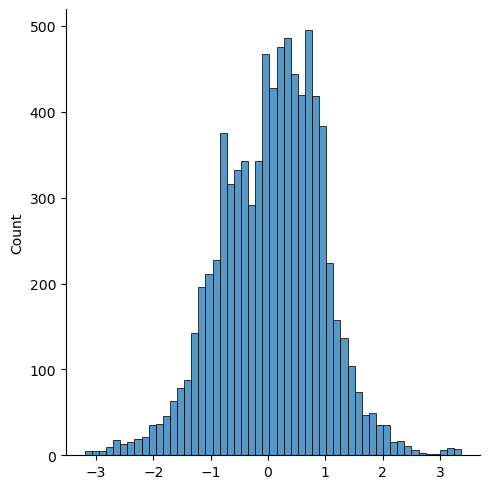

In [13]:
sns.displot(out['z_mu'].reshape(-1).detach().cpu())

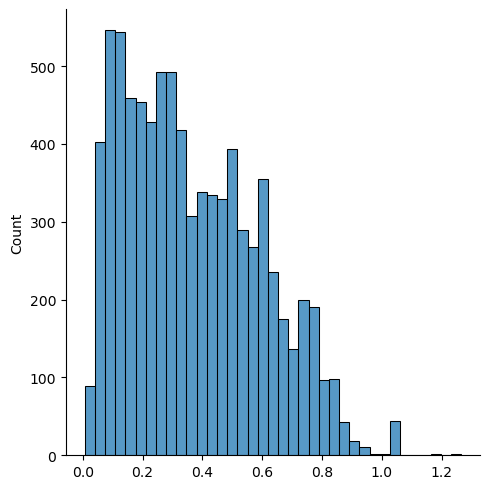

In [14]:
sns.displot(out['z_logvar'].exp().reshape(-1).detach().cpu())

In [15]:
len(loader.train_loader)

7

In [16]:
import seaborn as sns

In [17]:
trainer.dev_metrics

{0: {'train': {'loss': 1.0849555049623762,
   'mse': 0.7920528650283813,
   'rmse': 0.889973521232605,
   'mae': 0.6071332097053528,
   'r2': 0.7918683290481567,
   'kld': 27.307058334350586},
  'val': {'loss': 1.0717609524726868,
   'mse': 0.7990948557853699,
   'rmse': 0.8939210772514343,
   'mae': 0.6083328723907471,
   'r2': 0.7934607267379761,
   'kld': 45.8519172668457}},
 1: {'train': {'loss': 0.9881366746766227,
   'mse': 0.7377219200134277,
   'rmse': 0.8589074015617371,
   'mae': 0.5843830108642578,
   'r2': 0.8061449527740479,
   'kld': 59.84601974487305},
  'val': {'loss': 1.0284321308135986,
   'mse': 0.783947765827179,
   'rmse': 0.8854082226753235,
   'mae': 0.6020766496658325,
   'r2': 0.7973757386207581,
   'kld': 81.63192749023438}},
 2: {'train': {'loss': 0.956526517868042,
   'mse': 0.7286966443061829,
   'rmse': 0.8536372780799866,
   'mae': 0.5806271433830261,
   'r2': 0.8085165619850159,
   'kld': 94.2530288696289},
  'val': {'loss': 1.0011848211288452,
   'mse':